# **SEQ2SEQ**
# 1. Machine Translation
A basic example of the use of sequential data techniques is machine translation. This can be done using the Sequence to Sequence technique, which takes sequential data as input and outputs sequential data. This technique is used practically in a variety of situations, including translation between different languages, text summarization, and automatic greeting generation.

1. Machine translation execution and code reading
The following sample code does a short English to French translation.

In [1]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM
import os, keras
from pathlib import Path

batch_size = 64  # Batch size for training.
epochs = 5  # Number of epochs to train for.
latent_dim = 256  # Latent dimensionality of the encoding space.
num_samples = 10000  # Number of samples to train on.
# Path to the data txt file on disk.
data_path = '/kaggle/input/frac-eng/fra.txt'

"""
## Prepare the data
"""

# Vectorize the data.
input_texts = []
target_texts = []
input_characters = set()
target_characters = set()
with open(data_path, "r", encoding="utf-8") as f:
    lines = f.read().split("\n")
for line in lines[: min(num_samples, len(lines) - 1)]:
    input_text, target_text, _ = line.split("\t")
    # We use "tab" as the "start sequence" character
    # for the targets, and "\n" as "end sequence" character.
    target_text = "\t" + target_text + "\n"
    input_texts.append(input_text)
    target_texts.append(target_text)
    for char in input_text:
        if char not in input_characters:
            input_characters.add(char)
    for char in target_text:
        if char not in target_characters:
            target_characters.add(char)

input_characters = sorted(list(input_characters))
target_characters = sorted(list(target_characters))
num_encoder_tokens = len(input_characters)
num_decoder_tokens = len(target_characters)
max_encoder_seq_length = max([len(txt) for txt in input_texts])
max_decoder_seq_length = max([len(txt) for txt in target_texts])

print("Number of samples:", len(input_texts))
print("Number of unique input tokens:", num_encoder_tokens)
print("Number of unique output tokens:", num_decoder_tokens)
print("Max sequence length for inputs:", max_encoder_seq_length)
print("Max sequence length for outputs:", max_decoder_seq_length)

input_token_index = dict([(char, i) for i, char in enumerate(input_characters)])
target_token_index = dict([(char, i) for i, char in enumerate(target_characters)])

encoder_input_data = np.zeros(
    (len(input_texts), max_encoder_seq_length, num_encoder_tokens),
    dtype="float32",
)
decoder_input_data = np.zeros(
    (len(input_texts), max_decoder_seq_length, num_decoder_tokens),
    dtype="float32",
)
decoder_target_data = np.zeros(
    (len(input_texts), max_decoder_seq_length, num_decoder_tokens),
    dtype="float32",
)

for i, (input_text, target_text) in enumerate(zip(input_texts, target_texts)):
    for t, char in enumerate(input_text):
        encoder_input_data[i, t, input_token_index[char]] = 1.0
    encoder_input_data[i, t + 1 :, input_token_index[" "]] = 1.0
    for t, char in enumerate(target_text):
        # decoder_target_data is ahead of decoder_input_data by one timestep
        decoder_input_data[i, t, target_token_index[char]] = 1.0
        if t > 0:
            # decoder_target_data will be ahead by one timestep
            # and will not include the start character.
            decoder_target_data[i, t - 1, target_token_index[char]] = 1.0
    decoder_input_data[i, t + 1 :, target_token_index[" "]] = 1.0
    decoder_target_data[i, t:, target_token_index[" "]] = 1.0

"""
## Build the model
"""

# Define an input sequence and process it.
encoder_inputs = keras.Input(shape=(None, num_encoder_tokens))
encoder = keras.layers.LSTM(latent_dim, return_state=True)
encoder_outputs, state_h, state_c = encoder(encoder_inputs)

# We discard `encoder_outputs` and only keep the states.
encoder_states = [state_h, state_c]

# Set up the decoder, using `encoder_states` as initial state.
decoder_inputs = keras.Input(shape=(None, num_decoder_tokens))

# We set up our decoder to return full output sequences,
# and to return internal states as well. We don't use the
# return states in the training model, but we will use them in inference.
decoder_lstm = keras.layers.LSTM(latent_dim, return_sequences=True, return_state=True)
decoder_outputs, _, _ = decoder_lstm(decoder_inputs, initial_state=encoder_states)
decoder_dense = keras.layers.Dense(num_decoder_tokens, activation="softmax")
decoder_outputs = decoder_dense(decoder_outputs)

# Define the model that will turn
# `encoder_input_data` & `decoder_input_data` into `decoder_target_data`
model = keras.Model([encoder_inputs, decoder_inputs], decoder_outputs)

"""
## Train the model
"""

model.compile(
    optimizer="rmsprop", loss="categorical_crossentropy", metrics=["accuracy"]
)
model.fit(
    [encoder_input_data, decoder_input_data],
    decoder_target_data,
    batch_size=batch_size,
    epochs=epochs,
    validation_split=0.2,
)
# Save model
model.save("s2s_model.keras")

"""
## Run inference (sampling)

1. encode input and retrieve initial decoder state
2. run one step of decoder with this initial state
and a "start of sequence" token as target.
Output will be the next target token.
3. Repeat with the current target token and current states
"""

# Define sampling models
# Restore the model and construct the encoder and decoder.
model = keras.models.load_model("s2s_model.keras")

encoder_inputs = model.input[0]  # input_1
encoder_outputs, state_h_enc, state_c_enc = model.layers[2].output  # lstm_1
encoder_states = [state_h_enc, state_c_enc]
encoder_model = keras.Model(encoder_inputs, encoder_states)

decoder_inputs = model.input[1]  # input_2
decoder_state_input_h = keras.Input(shape=(latent_dim,))
decoder_state_input_c = keras.Input(shape=(latent_dim,))
decoder_states_inputs = [decoder_state_input_h, decoder_state_input_c]
decoder_lstm = model.layers[3]
decoder_outputs, state_h_dec, state_c_dec = decoder_lstm(
    decoder_inputs, initial_state=decoder_states_inputs
)
decoder_states = [state_h_dec, state_c_dec]
decoder_dense = model.layers[4]
decoder_outputs = decoder_dense(decoder_outputs)
decoder_model = keras.Model(
    [decoder_inputs] + decoder_states_inputs, [decoder_outputs] + decoder_states
)

# Reverse-lookup token index to decode sequences back to
# something readable.
reverse_input_char_index = dict((i, char) for char, i in input_token_index.items())
reverse_target_char_index = dict((i, char) for char, i in target_token_index.items())


def decode_sequence(input_seq):
    # Encode the input as state vectors.
    states_value = encoder_model.predict(input_seq, verbose=0)

    # Generate empty target sequence of length 1.
    target_seq = np.zeros((1, 1, num_decoder_tokens))
    # Populate the first character of target sequence with the start character.
    target_seq[0, 0, target_token_index["\t"]] = 1.0

    # Sampling loop for a batch of sequences
    # (to simplify, here we assume a batch of size 1).
    stop_condition = False
    decoded_sentence = ""
    while not stop_condition:
        output_tokens, h, c = decoder_model.predict(
            [target_seq] + states_value, verbose=0
        )

        # Sample a token
        sampled_token_index = np.argmax(output_tokens[0, -1, :])
        sampled_char = reverse_target_char_index[sampled_token_index]
        decoded_sentence += sampled_char

        # Exit condition: either hit max length
        # or find stop character.
        if sampled_char == "\n" or len(decoded_sentence) > max_decoder_seq_length:
            stop_condition = True

        # Update the target sequence (of length 1).
        target_seq = np.zeros((1, 1, num_decoder_tokens))
        target_seq[0, 0, sampled_token_index] = 1.0

        # Update states
        states_value = [h, c]
    return decoded_sentence


"""
## Generate decoded sentences as such:
"""

for seq_index in range(20):
    # Take one sequence (part of the training set)
    # for trying out decoding.
    input_seq = encoder_input_data[seq_index : seq_index + 1]
    decoded_sentence = decode_sequence(input_seq)
    print("-")
    print("Input sentence:", input_texts[seq_index])
    print("Decoded sentence:", decoded_sentence)

2025-04-28 09:37:25.303829: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1745833045.544254      13 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1745833045.619622      13 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


Number of samples: 10000
Number of unique input tokens: 70
Number of unique output tokens: 91
Max sequence length for inputs: 14
Max sequence length for outputs: 59


2025-04-28 09:37:42.228386: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Epoch 1/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 31s 222ms/step - accuracy: 0.7061 - loss: 1.5431 - val_accuracy: 0.7113 - val_loss: 1.0694
Epoch 2/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 28s 220ms/step - accuracy: 0.7451 - loss: 0.9604 - val_accuracy: 0.7184 - val_loss: 0.9776
Epoch 3/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 28s 220ms/step - accuracy: 0.7613 - loss: 0.8653 - val_accuracy: 0.7522 - val_loss: 0.8861
Epoch 4/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 27s 219ms/step - accuracy: 0.7847 - loss: 0.7773 - val_accuracy: 0.7775 - val_loss: 0.7887
Epoch 5/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 28s 221ms/step - accuracy: 0.8031 - loss: 0.6903 - val_accuracy: 0.7905 - val_loss: 0.7225
-
Input sentence: Go.
Decoded sentence: Come sous pais le !

-
Input sentence: Go.
Decoded sentence: Come sous pais le !

-
Input sentence: Go.
Decoded sentence: Come sous pais le !

-
Input sentence: Go.
Decoded sentence: Come sous pais le !

-
Input sentence: Hi.
Decoded sentence: Ce se sois pais.

-
Input sentence: Hi.
Decoded sentence: Ce se so

Line 1-6: Importing Libraries.

Line 8-12: Defining hyperparameters for the model. batch_size: Number of samples per training batch. epochs: Total number of times to iterate over the entire training dataset. latent_dim: Latent space dimensionality for the LSTM network (hidden state size). num_samples: Number of data samples to use for training. data_path: Path to the data file containing the French-English dataset.

Line 14-31: Reading and preparing the training data: input_texts, target_texts: Lists to store the source (French) and target (English) texts. input_characters, target_characters: Sets to store the unique characters in the input and target texts. The file is read line by line, and each line is split into input_text (French) and target_text (English). A special start-of-sequence (\t) and end-of-sequence (\n) character are added to the target text. The unique characters for both the source and target languages are collected.

Line 33-38: Calculating the number of unique characters and sequence lengths: The input_characters and target_characters sets are sorted into lists. num_encoder_tokens and num_decoder_tokens store the number of unique tokens in the input and target languages, respectively. max_encoder_seq_length and max_decoder_seq_length store the maximum length of input and target sequences.

Line 40-43: Creating mappings from characters to integer indices for both input and target languages.

Lines 45 to 56: Initializing arrays to store the one-hot encoded input and target data. encoder_input_data: Input data for the encoder. decoder_input_data: Input data for the decoder. decoder_target_data: The target data for the decoder, shifted by one timestep.

Lines 58 to 73: One-hot encoding the input and target texts for training: For each input_text and target_text, the characters are encoded as one-hot vectors and stored in the corresponding arrays. The target data for the decoder is shifted by one timestep.

Lines 75 to 91: Constructing the sequence-to-sequence model: The encoder consists of an LSTM layer that returns the hidden state and cell state. The decoder is another LSTM layer that takes the encoder's state as its initial state. The output of the decoder is passed through a Dense layer with a softmax activation to predict the next token in the sequence. The model is created by linking the encoder and decoder inputs to the decoder output.

Lines 93 to 96: Compiling the model with the RMSProp optimizer and categorical crossentropy loss function. Accuracy is used as a performance metric.

Lines 98 to 104: Training the model on the one-hot encoded data: The model is trained using the encoder and decoder input data, with the decoder target data as the target. The training is performed over epochs with a batch size of batch_size, and 20% of the data is used for validation.

Lines 106 to 108: Saving the trained model to a file for later use.

Lines 110 to 122: Defining the inference models for the encoder and decoder: encoder_model uses the encoder part of the trained model to return the encoder's states. decoder_model uses the decoder part of the model for inference, where the previous states are passed as inputs to predict the next character in the sequence.

Lines 124 to 131: The decode_sequence function generates the translated output for a given input sequence. It uses the encoder and decoder models to predict one token at a time until a stop condition (end-of-sequence token or maximum length) is met.

Lines 133 to 136: Testing the translation model: For each input sequence, the decode_sequence function is called to predict the output sentence. The input and decoded sentences are printed for comparison.

# 2. Image Captioning
Image captioning is the task of generating explanatory text for an image, and uses the Image to Sequence technique, which inputs an image and outputs sequence data. This technique is used in practice to generate descriptions of the surroundings of self-driving cars and to tag images for image search.

Image captioning requires a lot of time to train, so we use pre-trained weights. Since there is no easy-to-use Keras implementation, we use a PyTorch implementation

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth
100%|██████████| 97.8M/97.8M [00:00<00:00, 188MB/s]


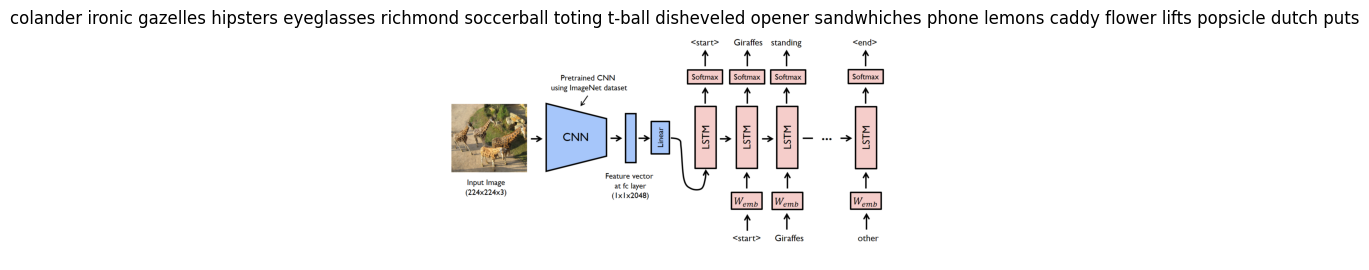

Generated Caption: colander ironic gazelles hipsters eyeglasses richmond soccerball toting t-ball disheveled opener sandwhiches phone lemons caddy flower lifts popsicle dutch puts


In [2]:
import torch
import torch.nn as nn
import torchvision.models as models
from torchvision.models import ResNet50_Weights
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
from PIL import Image
import matplotlib.pyplot as plt
import pickle

# Step 1: Define the Image Encoder (Feature Extractor)
class Encoder(nn.Module):
    def __init__(self, embed_size):
        super(Encoder, self).__init__()
        # Use the updated 'weights' parameter instead of 'pretrained'
        resnet = models.resnet50(weights=ResNet50_Weights.DEFAULT)  # Load pretrained weights
        # Remove the fully connected layer
        modules = list(resnet.children())[:-1]
        self.resnet = nn.Sequential(*modules)
        self.fc = nn.Linear(resnet.fc.in_features, embed_size)
        self.embed_size = embed_size

    def forward(self, images):
        with torch.no_grad():
            features = self.resnet(images)  # Extract features from image
        features = features.view(features.size(0), -1)  # Flatten
        features = self.fc(features)  # Linear layer to match embed_size
        return features


# Step 2: Define the Decoder (Caption Generator using LSTM)
class Decoder(nn.Module):
    def __init__(self, embed_size, hidden_size, vocab_size):
        super(Decoder, self).__init__()
        self.embed = nn.Embedding(vocab_size, embed_size)
        self.lstm = nn.LSTM(embed_size, hidden_size)
        self.fc = nn.Linear(hidden_size, vocab_size)
        self.dropout = nn.Dropout(p=0.5)

    def forward(self, features, captions):
        embeddings = self.embed(captions)
        embeddings = torch.cat((features.unsqueeze(1), embeddings), dim=1)
        hiddens, _ = self.lstm(embeddings)
        outputs = self.fc(hiddens)
        return outputs


# Step 3: Load Vocabulary (word2idx and idx2word mappings)
class Vocabulary:
    def __init__(self, word2idx, idx2word):
        self.word2idx = word2idx
        self.idx2word = idx2word
        
vocab_path = '/kaggle/input/vocab-pkl/vocab.pkl'
with open(vocab_path, 'rb') as f:
    vocab = pickle.load(f)

word2idx = vocab.word2idx
idx2word = vocab.idx2word
vocab_size = len(word2idx)


# Step 4: Preprocess Image
def preprocess_image(image_path):
    transform = transforms.Compose([
        transforms.Resize((256, 256)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])
    image = Image.open(image_path).convert('RGB')
    image = transform(image).unsqueeze(0)  # Add batch dimension
    return image


# Step 5: Load Pre-trained Models (Encoder and Decoder)
encoder = Encoder(embed_size=256)
decoder = Decoder(embed_size=256, hidden_size=512, vocab_size=vocab_size)

# Assuming you have pre-trained models saved
encoder_path = '/kaggle/input/pretrained-models/encoder-5-3000.pkl'
decoder_path = '/kaggle/input/pretrained-models/decoder-5-3000.pkl'

encoder.eval()
decoder.eval()


# Step 6: Generate Caption for an Image
def generate_caption(image_path):
    image = preprocess_image(image_path)
    image = image.to(torch.device('cuda' if torch.cuda.is_available() else 'cpu'))

    features = encoder(image)
    input_caption = torch.tensor([word2idx['<start>']]).unsqueeze(0).to(image.device)
    caption = []

    for i in range(20):  # Generate a caption of length 20
        outputs = decoder(features, input_caption)
        predicted = outputs.argmax(dim=2)[:, -1].item()
        word = idx2word[predicted]
        if word == '<end>':
            break
        caption.append(word)

        # Convert predicted index to tensor and unsqueeze to match the input format
        predicted_tensor = torch.tensor([predicted]).unsqueeze(0).to(image.device)
        input_caption = torch.cat((input_caption, predicted_tensor), dim=1)

    return ' '.join(caption)


# Step 7: Load Image and Display Caption
image_path = '/kaggle/input/image-captioning/image_captioning.png'  # Update with your image path
caption = generate_caption(image_path)
img = Image.open(image_path)
plt.imshow(img)
plt.axis('off')
plt.title(caption)
plt.show()

print("Generated Caption:", caption)


# 3. Investigate what to do if you want to run it with Keras
To run an image captioning model in Keras instead of PyTorch, we will need to follow a series of steps to make the transition smooth. 

1. Model Architecture in Keras - convert PyTorch model architecture to Keras which consists of Encoder (feature extractor): a CNN model based on ResNet50 and Decoder (Caption Generator): an LSTM model that generates captions.
2. Pre-trained weights in PyTorch to Keras - first export PyTorch weights by saving the weights in encoder and decoder, then load weights into Keras and match the weights manually from PyTorch to Keras.
3. Training the Keras model - once the weights are transferred we can train the Keras model using the usual training loops (fit).

# 4. (Advanced assignment) Code reading and rewriting
The model part is written in [model.py]. To rewrite the image captioning model in Keras, we need to break down the PyTorch code and create the corresponding Keras version. Below is the translation of the given PyTorch code to Keras, using TensorFlow/Keras components. We'll implement both the Encoder (CNN using a pre-trained ResNet152) and Decoder (RNN using LSTM) parts, and then combine them into a Captioning Model.

In [3]:
# Encoder - Feature Extraction
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, BatchNormalization, Flatten, Input
from tensorflow.keras.applications import ResNet152
import tensorflow as tf

class EncoderCNN(Model):
    def __init__(self, embed_size):
        super(EncoderCNN, self).__init__()
        # Load the ResNet152 pre-trained model
        resnet = ResNet152(weights='imagenet', include_top=False, input_shape=(256, 256, 3))
        self.resnet = resnet
        self.flatten = Flatten()
        self.linear = Dense(embed_size, activation='relu')
        self.bn = BatchNormalization(momentum=0.01)

    def call(self, images):
        """Extract feature vectors from input images."""
        features = self.resnet(images)
        features = self.flatten(features)
        features = self.bn(self.linear(features))
        return features


In [4]:
# Decoder - RNN(LSTM)
from tensorflow.keras.layers import LSTM, Embedding, Dense, Input, Dropout
from tensorflow.keras.models import Model
import tensorflow as tf

class DecoderRNN(Model):
    def __init__(self, embed_size, hidden_size, vocab_size, num_layers, max_seq_length=20):
        super(DecoderRNN, self).__init__()
        self.embed = Embedding(vocab_size, embed_size)
        self.lstm_layers = []
        for _ in range(num_layers):
            self.lstm_layers.append(LSTM(hidden_size, return_sequences=True, return_state=True))
        self.dense = Dense(vocab_size, activation='softmax')
        self.max_seq_length = max_seq_length

    def call(self, inputs, initial_state=None):
        captions, features = inputs
        x = self.embed(captions)
        x = tf.concat([features[:, tf.newaxis, :], x], axis=1)  # Concatenate image features with caption embeddings

        for lstm in self.lstm_layers:
            x, state_h, state_c = lstm(x, initial_state=initial_state)
            initial_state = [state_h, state_c]

        output = self.dense(x)
        return output

    def sample(self, features, states=None):
        sampled_ids = []
        inputs = features
        for _ in range(self.max_seq_length):
            x = self.embed(inputs)
            x = tf.concat([features[:, tf.newaxis, :], x], axis=1)
            for lstm in self.lstm_layers:
                x, state_h, state_c = lstm(x, initial_state=states)
                states = [state_h, state_c]
            outputs = self.dense(x)
            predicted = tf.argmax(outputs, axis=-1)
            sampled_ids.append(predicted)
            inputs = self.embed(predicted)

        return tf.stack(sampled_ids, axis=1)


In [5]:
# Combining into Captionining Model
class CaptioningModel(Model):
    def __init__(self, encoder, decoder):
        super(CaptioningModel, self).__init__()
        self.encoder = encoder
        self.decoder = decoder

    def call(self, images, captions, lengths):
        features = self.encoder(images)
        outputs = self.decoder([captions, features])
        return outputs

In [6]:
# Example
# Example hyperparameters
embed_size = 256
hidden_size = 512
vocab_size = 10000
num_layers = 2
max_seq_length = 20

# Initialize the Encoder and Decoder
encoder = EncoderCNN(embed_size)
decoder = DecoderRNN(embed_size, hidden_size, vocab_size, num_layers, max_seq_length)

# Combine into Captioning Model
captioning_model = CaptioningModel(encoder, decoder)

# Compile the model
captioning_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Example dummy input for testing
image_input = tf.random.uniform((32, 256, 256, 3))  # Batch of 32 images
caption_input = tf.random.uniform((32, max_seq_length), maxval=vocab_size, dtype=tf.int32)  # Random captions
lengths = tf.random.uniform((32,), minval=5, maxval=max_seq_length, dtype=tf.int32)  # Random lengths

# Forward pass through the model
outputs = captioning_model(image_input, caption_input, lengths)

print("Output shape:", outputs.shape)  # Expected shape: (batch_size, seq_len, vocab_size)


234698864/234698864 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step
Output shape: (32, 21, 10000)


# 5. (Advanced Issues) Advanced Research
**1. What if I need to translate into another language?**
- Preprocessing: Tokenize and normalize the text. For Japanese, use specialized tokenizers like MeCab or Janome.

- Model Training: Prepare a parallel corpus (source-target pairs). Use models like Neural Machine Translation (NMT) or transformer-based models like BERT or GPT for better performance.

- Postprocessing: After translation, fix grammatical issues and optimize the fluency of the generated text.

- Evaluation: Use metrics like BLEU, METEOR, and ROUGE to assess the translation quality.

**2. What are some advanced methods of machine translation?**
- Attention Mechanism: Improves sequence-to-sequence models by allowing the model to focus on relevant parts of the input sentence during translation, which is particularly useful for long sentences or languages with different word orders.

- Transformer-based Models: These models use self-attention to process input and output sequences in parallel, making them faster and more effective at capturing long-range dependencies in the text. Transformer models like BERT, GPT-3, and T5 are widely used in machine translation tasks.

- Multilingual Models: These models, like mBART and mT5, allow translation between multiple languages in a single model, improving scalability and efficiency.

- Few-shot and Zero-shot Translation: Techniques that allow models to translate languages with minimal labeled data or even no labeled data at all by leveraging pre-trained multilingual models.

**3. How to generate images from text?**
Generating images from text is a task in computer vision and natural language processing, with methods including:

- GANs (Generative Adversarial Networks): Models like AttnGAN use GANs to generate realistic images from text descriptions, utilizing attention mechanisms to focus on different parts of the text during image creation.

- Variational Autoencoders (VAEs): Conditional VAEs can generate images from text by encoding the text into a latent space and then decoding it into an image.

- CLIP + VQ-VAE-2: A combination of CLIP, which understands text-image relationships, and VQ-VAE-2, which generates high-quality images.

- DALL-E: OpenAI's transformer-based model generates creative and high-quality images from text descriptions by learning joint representations of text and images in a shared latent space.

- Diffusion Models: These models, such as Stable Diffusion, generate images by iteratively denoising a noisy image to match the given text description.

These methods use deep learning techniques to translate text descriptions into visually coherent and creative images, expanding the possibilities for visual content generation.
Please research the technology of generating images from text, which is the opposite of image captioning, and explain what methods are available.

